In [ ]:
import os
import requests
import subprocess

# OSMデータの保存先ディレクトリ
output_dir = 'data'

# ディレクトリが存在しない場合は作成
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
# OSMファイルのパス
osm_file = os.path.join(output_dir, 'map.osm')
# 出力するSUMOネットワークファイルのパス
net_file = os.path.join(output_dir, 'output.net.xml')

# SUMOの環境変数を設定
if not 'SUMO_HOME' in os.environ:
    os.environ['SUMO_HOME'] = "/opt/homebrew/opt/sumo/share/sumo" # SUMOのインストールパスを指定

# SUMOのホームディレクトリを設定
sumo_home = os.environ.get('SUMO_HOME')
if not sumo_home:
    raise EnvironmentError("Please set the 'SUMO_HOME' environment variable.")

# 既存のファイルを削除
#if os.path.exists(osm_file):
#    os.remove(osm_file)
#if os.path.exists(net_file):
#    os.remove(net_file)

# 1. Overpass APIでOSMデータを取得
取得する範囲のbounding boxを指定

In [2]:
# southern-most latitude, western-most longitude, northern-most latitude, eastern-most longitude
# bbox = (35.622933, 139.780158, 35.737156, 139.873833) # 江東区と墨田区を含む範囲
bbox = (35.622933, 139.780158, 35.703241, 139.853554) # 江東区の範囲

クエリの書き方
https://wiki.openstreetmap.org/wiki/Overpass_API/Overpass_API_by_Example

主な道路種別のフィルタリング例
- motorway: 高速道路
- trunk: 幹線道路
- primary: 主要道路
- secondary: 二次道路
- tertiary: 三次道路
- residential: 住宅地の道路
- service: サービス道路

自転車NWや歩行者NWなどいろんなネットワークを取り出せそう。
https://wiki.openstreetmap.org/wiki/JA:Key:highway

In [3]:
def getData(bbox):
    # Overpass APIエンドポイント
    overpass_url = "https://overpass-api.de/api/interpreter"
    
    # クエリ：特定の範囲のデータを取得
    # way["highway"~"trunk|primary|secondary|tertiary|residential|unclassified"]({bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]});
    overpass_query = f"""
    [out:xml];
    (
    way["highway"~"trunk|primary|secondary|tertiary|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]({bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]});
    node(w);
    relation["type"="restriction"]({bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]});
    );
    out body;
    >;
    out skel qt;
    """
    
    # APIリクエストを送信
    response = requests.get(overpass_url, params={'data': overpass_query})
    
    return response.text

data = getData(bbox)

# OSMデータをファイルに保存
with open(osm_file, 'w') as f:
    f.write(data)

print(f"OSM data saved to {osm_file}")


OSM data saved to data/map.osm


# 2. OSMデータを表示してみる

* motorway: 赤
* trunk: オレンジ
* primary: 青
* secondary: 緑
* tertiary: 紫
* residential: グレー

In [4]:
import folium
import osmnx as ox
import xml.etree.ElementTree as ET

# XMLツリーをパース
tree = ET.parse(osm_file)
root = tree.getroot()

# 地図を作成
# 初期表示の中心座標を設定
latitude, longitude = (bbox[0]+bbox[2])/2, (bbox[1]+bbox[3])/2

mymap = folium.Map(location=[latitude, longitude], zoom_start=14)

# 道路種別ごとの色設定
road_colors = {
    "motorway": "red",
    "trunk": "orange",
    "primary": "blue",
    "secondary": "green",
    "tertiary": "purple",
    "residential": "gray"
}

# ノードを収集
nodes = {}
for node in root.findall('node'):
    node_id = node.get('id')
    lat = float(node.get('lat'))
    lon = float(node.get('lon'))
    nodes[node_id] = (lat, lon)
    # ノードを地図に追加 (サイズを大きく設定)
    # folium.CircleMarker(location=(lat, lon), radius=1.5, opacity = 0.8, color='black', fill=True).add_to(mymap)


# ウェイを地図に追加
for way in root.findall('way'):
    nds = way.findall('nd')
    latlons = []
    for nd in nds:
        ref = nd.get('ref')
        if ref in nodes:
            latlons.append(nodes[ref])

    # 道路種別を取得
    highway_tag = None
    for tag in way.findall('tag'):
        if tag.get('k') == 'highway':
            highway_tag = tag.get('v')
            break

    # 色を設定
    color = road_colors.get(highway_tag, "black")  # 未指定の場合は黒

    # ウェイを地図に追加
    if latlons:
        folium.PolyLine(latlons, color=color).add_to(mymap)

# 地図を保存して表示
mymap.save(os.path.join(output_dir, 'osm_map.html'))
print("Map has been saved as osm_map.html")

Map has been saved as osm_map.html


# 3. OSMデータをSUMOネットワークに変換
SUMOにデフォルトで付随するnetconvertツールを使用する。

https://sumo.dlr.de/docs/Networks/Import/OpenStreetMap.html#traffic_lights

日本独自の設定については以下の記事を参照。

https://qiita.com/h-masano/items/5581ac3cc02356911c85

In [5]:
# osmファイルをnet.xmlに変換するコマンド
# `simple-projection`オプションを使用
netconvert_cmd = [
    os.path.join(sumo_home, 'bin', 'netconvert'),
    '--osm-files', osm_file,
    '--output-file', net_file,
    '--speed-in-kmh', # 速度をkm/hで指定
    '--junctions.join', # 近接している交差点を結合する
    '--tls.guess', # OSM上に存在しない交差点もルールベースで追加する
    '--tls.guess.threshold', '39.0', # 交差点を設置する道路の制限速度の最小値
    '--tls.guess-signals', # OSM上に存在しない信号もルールベースで追加する
    '--tls.discard-simple', # 単純な交差点（単一の接続道路が1つだけの交差点）に交通信号を設置しない
    '--tls.join', # 近接している信号機を一体の構成とみなす
    '--lefthand', # 左側通行の設定
    '--proj.utm',  # ここでUTM投影法を指定
    '--geometry.remove', # 余分なジオメトリを削除
    '--ramps.guess', # Acceleration/Deceleration lanes are often not included in OSM data. This option identifies roads that likely have these additional lanes and adds them
    '--ignore-errors',  # エラーを無視
]

# コマンドを実行
subprocess.run(netconvert_cmd, check=True)
print(f"SUMO network file created at {net_file}")


# GeoJsonファイルを作成
geojson_file = os.path.join(output_dir, 'output.geojson')
net2geojson_cmd = [
    os.path.join(sumo_home, 'tools', 'net', 'net2geojson.py'),
    '-n', net_file,
    '-o', geojson_file,
    '--lanes', # write lane geometries
    '--internal' # write junction-internal edges or lanes
]
# コマンドを実行
subprocess.run(net2geojson_cmd, check=True)
print(f"GeoJson file created at {geojson_file}")


pj_obj_create: /Users/masudasatoki/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
pj_obj_create: /Users/masudasatoki/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


Success.
SUMO network file created at data/output.net.xml
GeoJson file created at data/output.geojson


# 4. コントラフローネットワークの作成

Contraflow network generator (safe):
- Expand numLanes for target edges (2x)
- Let netconvert infer connections WITHOUT feeding connection-files
- Extract ONLY connections that start from expanded edges' extra lanes (fromLane >= orig_n)
  (so normal lanes from other edges cannot enter extra lanes)
- Build final network by feeding: plain.con.xml + extra.con.xml

In [ ]:
import os
import subprocess
from pathlib import Path
from typing import Dict, List, Set, Tuple

import pandas as pd
import lxml.etree as ET
import sumolib

def parse_targets(contraflow_csv: Path) -> Tuple[Dict[str, int], Dict[str, int]]:
    """
    returns:
      targets_numlanes: edge_id -> 2*orig_n
      orig_lanes_map:   edge_id -> orig_n
    """
    df = pd.read_csv(contraflow_csv)
    targets_numlanes: Dict[str, int] = {}
    orig_lanes_map: Dict[str, int] = {}

    for _, r in df.iterrows():
        epos = str(r["edge_pos"])
        eneg = str(r["edge_neg"])
        npos = int(r["orig_lanes_pos"])
        nneg = int(r["orig_lanes_neg"])

        targets_numlanes[epos] = 2 * npos
        targets_numlanes[eneg] = 2 * nneg
        orig_lanes_map[epos] = npos
        orig_lanes_map[eneg] = nneg

    return targets_numlanes, orig_lanes_map

if not 'SUMO_HOME' in os.environ:
    os.environ['SUMO_HOME'] = "/opt/homebrew/opt/sumo/share/sumo" # SUMOのインストールパスを指定
SUMO_HOME = os.environ.get('SUMO_HOME')
if not SUMO_HOME:
    raise RuntimeError("SUMO_HOME is not set.")

sumo_bin = Path(SUMO_HOME) / "bin"
netconvert = str(sumo_bin / "netconvert")

data_dir = Path("data")
tmp_dir = data_dir / "tmp"
tmp_dir.mkdir(parents=True, exist_ok=True)

net_file = data_dir / "output.net.xml"
contraflow_csv = data_dir / "contraflow.csv"

out_net = data_dir / "output_contraflow.net.xml"

# ---- 0) targets ----
targets_numlanes, orig_lanes_map = parse_targets(contraflow_csv)

## contraflow用の追加レーンを作る

plain化

In [5]:
os.makedirs(tmp_dir, exist_ok=True)
plain_prefix = tmp_dir / "plain"
net_cmd = [
    netconvert,
    '--sumo-net-file', str(net_file),
    '--plain-output-prefix', str(plain_prefix),
]

# コマンドを実行
subprocess.run(net_cmd, check=True)

plain_nod = tmp_dir / "plain.nod.xml"
plain_edg = tmp_dir / "plain.edg.xml"
plain_con = tmp_dir / "plain.con.xml"
plain_typ = tmp_dir / "plain.typ.xml"
plain_tll = tmp_dir / "plain.tll.xml"

Success.


tmp/plain.edg.xml のうち、contraflow.csv にある edge_pos/edge_neg の numLanes を 2*orig_lanes にする

In [6]:
def patch_plain_edg(plain_edg: Path, out_edg: Path, targets_numlanes: Dict[str, int]) -> int:
    tree = ET.parse(str(plain_edg))
    root = tree.getroot()
    cnt = 0
    for e in root.findall("edge"):
        eid = e.get("id")
        if eid in targets_numlanes:
            e.set("numLanes", str(targets_numlanes[eid]))
            cnt += 1
    tree.write(str(out_edg), pretty_print=True, xml_declaration=True, encoding="UTF-8")
    return cnt

patched_edg = tmp_dir / "plain_contraflow.edg.xml"
cnt = patch_plain_edg(plain_edg, patched_edg, targets_numlanes)
print("[info] patched edges:", cnt)

[info] patched edges: 378


再生成して contraflow対応ネットワークを作る

'--connection-files', os.path.join(output_dir, 'tmp', 'plain.con.xml'), # これを入れると追加レーンと元のレーンの接続が生成されずcontraflowの効果がなくなる

In [9]:
infer_prefix = tmp_dir / "infer"
infer_net = tmp_dir / "infer.net.xml"

infer_cmd = [
    netconvert,
    "--node-files", str(plain_nod),
    "--edge-files", str(patched_edg),
    '--type-files', str(plain_typ),
    #'--tllogic-files', str(plain_tll),
    "--output-file", str(infer_net),
    "--plain-output-prefix", str(infer_prefix),
]
subprocess.run(infer_cmd, check=True)

infer_con = tmp_dir / "infer.con.xml"
if not infer_con.exists():
    # netconvert uses prefix + ".con.xml"
    infer_con = Path(str(infer_prefix) + ".con.xml")
if not infer_con.exists():
    raise RuntimeError("infer.con.xml was not generated. Check netconvert output.")

Success.


In [10]:
def load_existing_conn_keys(con_xml: Path) -> Set[Tuple[str, str, str, str, str]]:
    """
    Keep a conservative key to avoid duplicates.
    key = (from, to, fromLane, toLane, via)
    """
    keys: Set[Tuple[str, str, str, str, str]] = set()
    if not con_xml.exists():
        return keys
    tree = ET.parse(str(con_xml))
    root = tree.getroot()
    for c in root.findall("connection"):
        keys.add((
            c.get("from", ""),
            c.get("to", ""),
            c.get("fromLane", ""),
            c.get("toLane", ""),
            c.get("via", ""),
        ))
    return keys

def build_extra_con(
    infer_con: Path,
    baseline_con: Path,
    out_extra_con: Path,
    orig_lanes_map: Dict[str, int],
) -> int:
    """
    Extract connections that:
      - fromEdge is a contraflow-expanded edge (in orig_lanes_map)
      - fromLane >= orig_n   (extra lanes only)
    This prevents "normal state" vehicles from other edges entering extra lanes.
    """
    infer_tree = ET.parse(str(infer_con))
    infer_root = infer_tree.getroot()

    existing = load_existing_conn_keys(baseline_con)

    out_root = ET.Element("connections")
    added = 0

    for c in infer_root.findall("connection"):
        fe = c.get("from")
        fl = c.get("fromLane")
        if fe is None or fl is None:
            continue
        if fe not in orig_lanes_map:
            continue
        try:
            fl_i = int(fl)
        except ValueError:
            continue

        orig_n = orig_lanes_map[fe]
        if fl_i < orig_n:
            continue  # keep only extra lanes

        key = (
            c.get("from", ""),
            c.get("to", ""),
            c.get("fromLane", ""),
            c.get("toLane", ""),
            c.get("via", ""),
        )
        if key in existing:
            continue

        out_root.append(ET.fromstring(ET.tostring(c)))
        added += 1

    ET.ElementTree(out_root).write(
        str(out_extra_con),
        pretty_print=True,
        xml_declaration=True,
        encoding="UTF-8",
    )
    return added

# ---- 4) build extra.con.xml (extra lanes only) ----
extra_con = tmp_dir / "extra.con.xml"
added = build_extra_con(infer_con, plain_con, extra_con, orig_lanes_map)
print("[info] extra connections added:", added)

# ---- 5) build final contraflow net: baseline con + extra con ----
final_cmd = [
    netconvert,
    "--node-files", str(plain_nod),
    "--edge-files", str(patched_edg),
    "--type-files", str(plain_typ),
    "--tllogic-files", str(plain_tll),
    "--connection-files", f"{plain_con},{extra_con}",
    "--output-file", str(out_net),
]

subprocess.run(final_cmd, check=True)

print("[done] wrote:", out_net)

[info] extra connections added: 1059


Success.
[done] wrote: data/output_contraflow.net.xml


# 5. 図化

Number of edges in the original SUMO graph: 12799
Number of nodes in the networkx graph: 5528
Number of edges in the networkx graph: 12674
Created graphs successfully


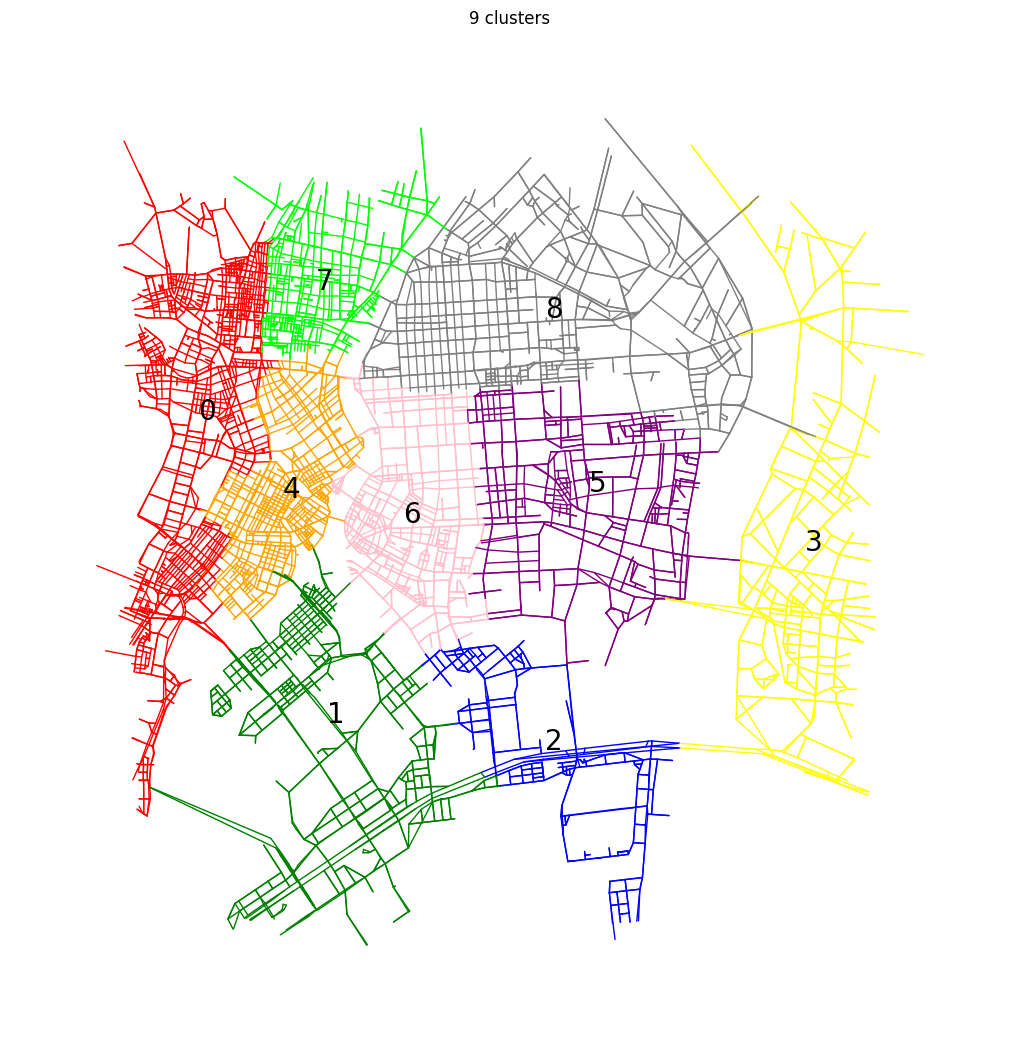

In [21]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

network_path="../../reconfigration/data/raw/network.geojson"
cluster_path="../../reconfigration/data/raw/zoning.csv"
output_dir="plot"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

network = None
G = None
S = None
edges = {}

# load_network
network = gpd.read_file(network_path)
cluster_df = pd.read_csv(cluster_path, encoding='utf-8')
clusters = [cluster_df[column].dropna().to_list() for column in cluster_df.columns]
cluster2edge = {cluster_id: cluster_df[column].dropna().to_list() for cluster_id, column in enumerate(cluster_df.columns)}
edge2cluster = {edge_id: cluster_id for cluster_id, cluster in enumerate(clusters) for edge_id in cluster}

# def extract_edges
for _, row in network.iterrows():
    coords = row['geometry'].coords
    if len(coords) > 1:
        start = coords[0]
        end = coords[-1]
        edge = (tuple(start), tuple(end))
        edges[row['id']] = edge
print("Number of edges in the original SUMO graph:", len(edges))

G = nx.MultiGraph()
for edge_id, (start, end) in edges.items():
    G.add_edges_from(
        [(start, end)], id=edge_id
    )
edge_threshold=100
connected_components = list(nx.connected_components(G))
nodes_to_remove = []
for component in connected_components:
    subgraph = G.subgraph(component)
    if subgraph.number_of_edges() <= edge_threshold:
        nodes_to_remove.extend(list(component))
G.remove_nodes_from(nodes_to_remove)
print("Number of nodes in the networkx graph:", len(list(G.nodes)))
print("Number of edges in the networkx graph:", len(list(G.edges)))

S = nx.line_graph(G)
for s, t, x in G.edges:
    S.nodes[(s, t, x)]['id'] = G.edges[(s, t, x)]['id']
id2node_dict = {edge_id: (s, t, x) for (s, t, x), edge_id in S.nodes(data='id')}

print("Created graphs successfully")
        
  
color_list = [
    'Red', 'Green', 'Blue', 'Yellow', 'Orange', 'Purple', 'Pink',
    'Lime',  'Gray', 'Cyan', 'Magenta', 'Brown',
    'Maroon', 'Navy', 'Olive', 'Teal', 'Aqua', 'Silver', 'Coral', 'Black'
]
colors = color_list[:len(clusters)]
node_color_map = {}

for cluster_id, cluster in enumerate(clusters):
    for edge_id in cluster:
        node = id2node_dict[edge_id]
        node_color_map[node] = colors[cluster_id]

color_map = [node_color_map[edge] for edge in G.edges]
pos = {node: (node[0], node[1]) for node in G.nodes()}

plt.figure(figsize=(10, 10))
nx.draw(G, pos, edge_color=color_map, with_labels=False, node_size=0, font_size=8)
plt.title(f"{len(clusters)} clusters")
# クラスター番号を記載
for i, cluster in enumerate(clusters):
    #print(f"cluster_{i}: {cluster}")
    cluster_x = sum([(id2node_dict[edge_id][0][0] + id2node_dict[edge_id][1][0])/2 for edge_id in cluster])/len(cluster)
    cluster_y = sum([(id2node_dict[edge_id][0][1] + id2node_dict[edge_id][1][1])/2 for edge_id in cluster])/len(cluster)
    plt.text(cluster_x, cluster_y, f"{i}", fontsize=20, color='black')

plt.savefig(f"{output_dir}/clusters.png", bbox_inches='tight', dpi=300)
plt.show()

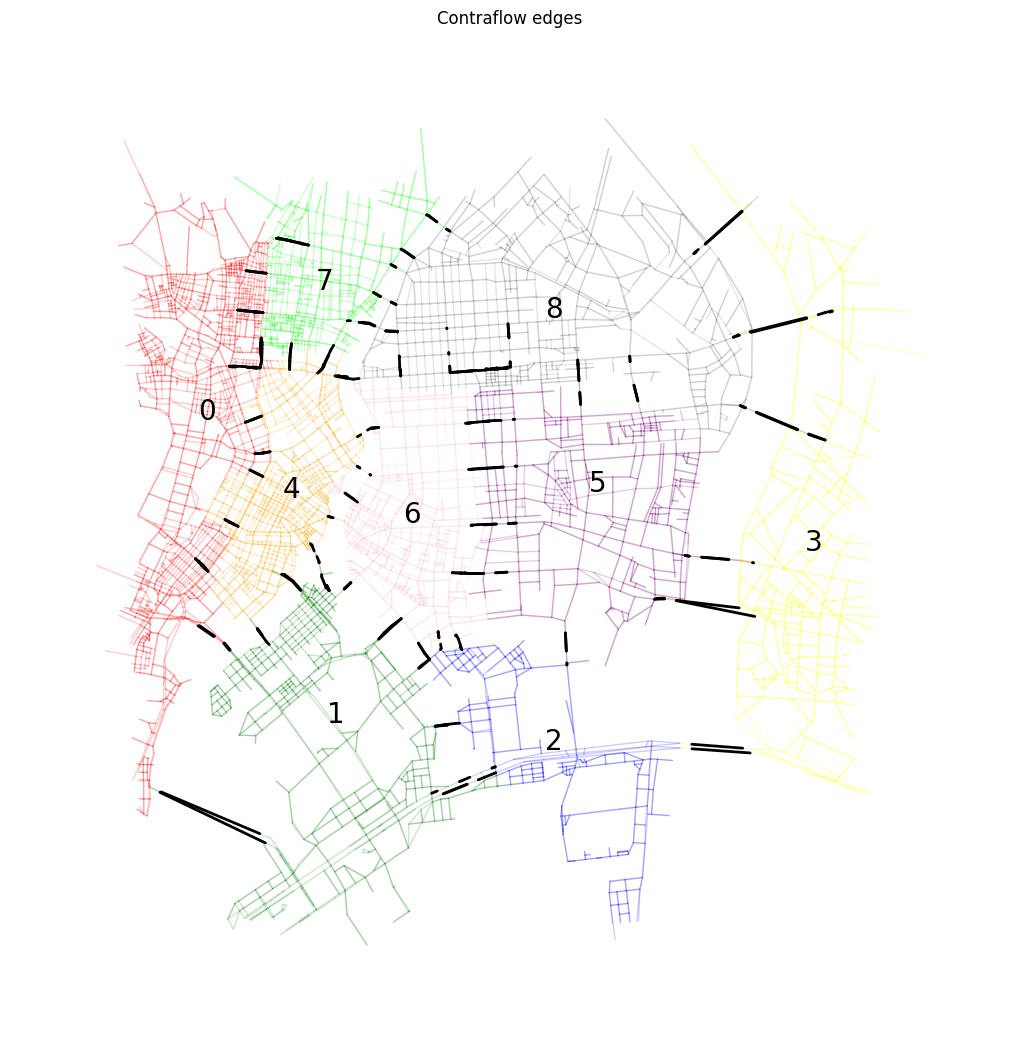

In [24]:
# contraflow.csvを読み込んで、contraflowリンクを描画
df = pd.read_csv("data/contraflow.csv")
contraflow_edges = []
for _, r in df.iterrows():
    epos = str(r["edge_pos"])
    eneg = str(r["edge_neg"])
    contraflow_edges.append(epos)
    contraflow_edges.append(eneg)
contraflow_nodes = [id2node_dict[edge_id] for edge_id in contraflow_edges if edge_id in id2node_dict]
contraflow_color_map = ['Black' for _ in contraflow_nodes]

plt.figure(figsize=(10, 10))
nx.draw(G, pos, edge_color=color_map, with_labels=False, node_size=0, font_size=8, alpha=0.2)
nx.draw_networkx_edges(G, pos, edgelist=contraflow_nodes, edge_color=contraflow_color_map, width=2)
# クラスター番号を記載
for i, cluster in enumerate(clusters):
    #print(f"cluster_{i}: {cluster}")
    cluster_x = sum([(id2node_dict[edge_id][0][0] + id2node_dict[edge_id][1][0])/2 for edge_id in cluster])/len(cluster)
    cluster_y = sum([(id2node_dict[edge_id][0][1] + id2node_dict[edge_id][1][1])/2 for edge_id in cluster])/len(cluster)
    plt.text(cluster_x, cluster_y, f"{i}", fontsize=20, color='black')

plt.title(f"Contraflow edges")
plt.savefig(f"{output_dir}/contraflow_edges.png", bbox_inches='tight', dpi=300)
plt.show()


In [25]:
# GIS用にnetworkにcluster列とcontraflow列を追加して保存
network['cluster'] = network['id'].map(edge2cluster).fillna(-1).astype(int)
network['contraflow'] = network['id'].apply(lambda x: 1 if x in contraflow_edges else 0)
network.to_file(f"{output_dir}/network_with_clusters_contraflow.geojson", driver='GeoJSON')